In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
df=pd.read_csv('C:/Users/ssbra/OneDrive/Documents/Python_Diwali_Sales_Analysis/dataset.csv')
#df.shape
#df.info()
#df.describe()
#drop blank columns
df.drop(columns=['Status','unnamed1'],inplace=True)
#check for null values
df.isnull().sum()
#drop null values
df.dropna(inplace=True)
#df.head(20)
#check for valid data here
df = df[df['Product_ID'] != 'Changed_Value']
(df['Product_ID'] == 'Changed_Value').sum() 
df.columns




Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [2]:
df.shape

(10582, 13)

In [3]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [4]:
#fill missing values
df.fillna({
    'User_ID': 0,
    'Cust_name': "Unknown",
    'Product_ID': "Not Available",
    'Amount': df['Amount'].mean()
}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10582 entries, 1 to 12375
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           10582 non-null  float64
 1   Cust_name         10582 non-null  object 
 2   Product_ID        10582 non-null  object 
 3   Gender            10582 non-null  object 
 4   Age Group         10582 non-null  object 
 5   Age               10582 non-null  float64
 6   Marital_Status    10582 non-null  float64
 7   State             10582 non-null  object 
 8   Zone              10582 non-null  object 
 9   Occupation        10582 non-null  object 
 10  Product_Category  10582 non-null  object 
 11  Orders            10582 non-null  float64
 12  Amount            10582 non-null  float64
dtypes: float64(5), object(8)
memory usage: 1.1+ MB


In [5]:
df.shape

(10582, 13)

In [6]:
df['User_ID']=df['User_ID'].astype(int)
df['Orders']=df['Orders'].astype(int)
df['Amount']=df['Amount'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10582 entries, 1 to 12375
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           10582 non-null  int64  
 1   Cust_name         10582 non-null  object 
 2   Product_ID        10582 non-null  object 
 3   Gender            10582 non-null  object 
 4   Age Group         10582 non-null  object 
 5   Age               10582 non-null  float64
 6   Marital_Status    10582 non-null  float64
 7   State             10582 non-null  object 
 8   Zone              10582 non-null  object 
 9   Occupation        10582 non-null  object 
 10  Product_Category  10582 non-null  object 
 11  Orders            10582 non-null  int64  
 12  Amount            10582 non-null  int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 1.1+ MB


In [7]:
#Rename Columns (clean format)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10582 entries, 1 to 12375
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10582 non-null  int64  
 1   cust_name         10582 non-null  object 
 2   product_id        10582 non-null  object 
 3   gender            10582 non-null  object 
 4   age_group         10582 non-null  object 
 5   age               10582 non-null  float64
 6   marital_status    10582 non-null  float64
 7   state             10582 non-null  object 
 8   zone              10582 non-null  object 
 9   occupation        10582 non-null  object 
 10  product_category  10582 non-null  object 
 11  orders            10582 non-null  int64  
 12  amount            10582 non-null  int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 1.1+ MB


In [8]:
#Handle Wrong Values
df['gender'] = df['gender'].str.upper()
df['gender'] = df['gender'].replace("CHANGED_VALUE", "M")
(df['gender'] == "CHANGED_VALUE").sum()
mode_value = df['product_id'].mode()[0]
df.loc[df['product_id'] == 'Changed_Value', 'product_id'] = mode_value
df['product_id'] = df['product_id'].replace({
    'Changed_Value': 'P00234565'
    })
mode_value = df['occupation'].mode()[0]
df.loc[df['occupation'] == 'Changed_Value', 'occupation'] = mode_value
mode_value = df['product_category'].mode()[0]
df.loc[df['product_category'] == 'Changed_Value', 'product_category'] = mode_value
mode_value = df['zone'].mode()[0]
df.loc[df['zone'] == 'Changed_Value', 'zone'] = mode_value
#(df['gender'] == "CHANGED_VALUE").sum()
#(df['zone'] == 'Changed_Value').sum() 
#(df['product_id'] == 'Changed_Value').sum() 
#(df['occupation'] == 'Changed_Value').sum() 
(df['product_category'] == 'Changed_Value').sum() 
#df.head(20)

np.int64(0)

In [9]:
#Create New Column
df['total_sales'] = df['orders'] * df['amount']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10582 entries, 1 to 12375
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10582 non-null  int64  
 1   cust_name         10582 non-null  object 
 2   product_id        10582 non-null  object 
 3   gender            10582 non-null  object 
 4   age_group         10582 non-null  object 
 5   age               10582 non-null  float64
 6   marital_status    10582 non-null  float64
 7   state             10582 non-null  object 
 8   zone              10582 non-null  object 
 9   occupation        10582 non-null  object 
 10  product_category  10582 non-null  object 
 11  orders            10582 non-null  int64  
 12  amount            10582 non-null  int64  
 13  total_sales       10582 non-null  int64  
dtypes: float64(2), int64(4), object(8)
memory usage: 1.2+ MB


In [10]:
df.isnull().sum()

user_id             0
cust_name           0
product_id          0
gender              0
age_group           0
age                 0
marital_status      0
state               0
zone                0
occupation          0
product_category    0
orders              0
amount              0
total_sales         0
dtype: int64

In [11]:
df['marital_status']=df['marital_status'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10582 entries, 1 to 12375
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10582 non-null  int64  
 1   cust_name         10582 non-null  object 
 2   product_id        10582 non-null  object 
 3   gender            10582 non-null  object 
 4   age_group         10582 non-null  object 
 5   age               10582 non-null  float64
 6   marital_status    10582 non-null  int64  
 7   state             10582 non-null  object 
 8   zone              10582 non-null  object 
 9   occupation        10582 non-null  object 
 10  product_category  10582 non-null  object 
 11  orders            10582 non-null  int64  
 12  amount            10582 non-null  int64  
 13  total_sales       10582 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 1.2+ MB


In [12]:
df.head(20)

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,total_sales
1,1000732,Kartik,P00110942,F,26-35,35.0,1,Andhra Pradesh,Southern,Govt,Auto,3,23934,71802
2,1502985,Bindu,P00118542,F,26-35,52.5,1,Uttar Pradesh,Central,Automobile,Auto,4,35886,143544
4,1000588,Joni,P00057942,M,26-35,28.0,1,Gujarat,Western,Food Processing,Auto,2,23877,47754
5,1500882,Joni,P00057942,M,26-35,42.0,1,Himachal Pradesh,Northern,Food Processing,Auto,1,35815,35815
6,1001132,Balk,P00018042,F,18-25,25.0,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841,95364
8,1003224,Kushal,P00205642,M,26-35,35.0,0,Uttar Pradesh,Central,Govt,Auto,2,23809,47618
9,1003650,Ginny,P00031142,F,26-35,26.0,1,Andhra Pradesh,Southern,Media,Auto,4,23799,95196
10,1003829,Harshita,P00200842,M,26-35,34.0,0,Delhi,Central,Banking,Auto,1,23770,23770
11,1000214,Kargatis,P00119142,F,18-25,20.0,0,Andhra Pradesh,Southern,Retail,Auto,2,23752,47504
12,1004035,Elijah,P00080342,F,18-25,20.0,1,Andhra Pradesh,Southern,IT Sector,Auto,2,23730,47460


In [13]:
df['marital_status']=df['marital_status'].astype(int)
df['marital_status'] = df['marital_status'].replace({
    0: 'Single',
    1: 'Married'
})

In [14]:
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 10582 entries, 1 to 12375
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10582 non-null  int64  
 1   cust_name         10582 non-null  object 
 2   product_id        10582 non-null  object 
 3   gender            10582 non-null  object 
 4   age_group         10582 non-null  object 
 5   age               10582 non-null  float64
 6   marital_status    10582 non-null  object 
 7   state             10582 non-null  object 
 8   zone              10582 non-null  object 
 9   occupation        10582 non-null  object 
 10  product_category  10582 non-null  object 
 11  orders            10582 non-null  int64  
 12  amount            10582 non-null  int64  
 13  total_sales       10582 non-null  int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 1.2+ MB


,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,total_sales
1,1000732,Kartik,P00110942,F,26-35,35.0,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934,71802
2,1502985,Bindu,P00118542,F,26-35,52.5,Married,Uttar Pradesh,Central,Automobile,Auto,4,35886,143544
4,1000588,Joni,P00057942,M,26-35,28.0,Married,Gujarat,Western,Food Processing,Auto,2,23877,47754
5,1500882,Joni,P00057942,M,26-35,42.0,Married,Himachal Pradesh,Northern,Food Processing,Auto,1,35815,35815
6,1001132,Balk,P00018042,F,18-25,25.0,Married,Uttar Pradesh,Central,Lawyer,Auto,4,23841,95364
8,1003224,Kushal,P00205642,M,26-35,35.0,Single,Uttar Pradesh,Central,Govt,Auto,2,23809,47618
9,1003650,Ginny,P00031142,F,26-35,26.0,Married,Andhra Pradesh,Southern,Media,Auto,4,23799,95196
10,1003829,Harshita,P00200842,M,26-35,34.0,Single,Delhi,Central,Banking,Auto,1,23770,23770
11,1000214,Kargatis,P00119142,F,18-25,20.0,Single,Andhra Pradesh,Southern,Retail,Auto,2,23752,47504
12,1004035,Elijah,P00080342,F,18-25,20.0,Married,Andhra Pradesh,Southern,IT Sector,Auto,2,23730,47460


In [15]:
df['marital_status'].unique()

array(['Married', 'Single'], dtype=object)

In [16]:
df.isnull().sum()

user_id             0
cust_name           0
product_id          0
gender              0
age_group           0
age                 0
marital_status      0
state               0
zone                0
occupation          0
product_category    0
orders              0
amount              0
total_sales         0
dtype: int64

In [17]:
#calculating totalsale per state
df.groupby('state')['total_sales'].sum()
df['state'] = df['state'].replace("Changed_Value", df['state'].mode()[0])
(df['state'] == "Changed_Value").sum()
df['state'] = df['state'].astype(str)
df['state'] = df['state'].str.replace('\xa0', ' ', regex=False)
df['state'] = df['state'].str.strip()
df['state'].unique()


array(['Andhra Pradesh', 'Uttar Pradesh', 'Gujarat', 'Himachal Pradesh',
       'Delhi', 'Karnataka', 'Kerala', 'Haryana', 'Maharashtra',
       'Madhya Pradesh', 'Jharkhand', 'Bihar', 'Rajasthan', 'Uttarakhand',
       'Telangana', 'Punjab'], dtype=object)

In [18]:
df['product_category'].value_counts()

product_category
Clothing & Apparel       2510
Food                     2339
Electronics & Gadgets    1955
Footwear & Shoes         1006
Household items           475
Beauty                    395
Games & Toys              379
Sports Products           332
Furniture                 329
Pet Care                  211
Office                    105
Stationery                102
Books                      98
Auto                       92
Decor                      88
Veterinary                 72
Tupperware                 71
Hand & Power Tools         23
Name: count, dtype: int64

In [31]:
#top selling state
top_state =df.groupby('state')['total_sales'].sum().sort_values(ascending=False)
print(top_state)
df['top_state'] = top_state

state
Uttar Pradesh       49762027
Maharashtra         37253599
Karnataka           34179342
Delhi               29657571
Andhra Pradesh      21257071
Madhya Pradesh      21215342
Himachal Pradesh    13137384
Haryana             11460504
Bihar               10674162
Gujarat             10421374
Kerala              10137214
Jharkhand            8135696
Uttarakhand          6907175
Rajasthan            4574813
Punjab               3704696
Telangana            3104678
Name: total_sales, dtype: int64


In [20]:
#top  three state
top_state.head(3)

state
Uttar Pradesh    49762027
Maharashtra      37253599
Karnataka        34179342
Name: total_sales, dtype: int64

In [49]:
#top customer
top_customer=df.groupby('cust_name')['total_sales'].sum().sort_values(ascending=False).head(10)
df['top_customer'] = df['cust_name'].map(top_customer)
top_customer.head(15)
df.head(115)


,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,total_sales,top_state,top_customer
1,1000732,Kartik,P00110942,F,26-35,35.0,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934,71802,NaN,NaN
2,1502985,Bindu,P00118542,F,26-35,52.5,Married,Uttar Pradesh,Central,Automobile,Auto,4,35886,143544,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28.0,Married,Gujarat,Western,Food Processing,Auto,2,23877,47754,NaN,NaN
5,1500882,Joni,P00057942,M,26-35,42.0,Married,Himachal Pradesh,Northern,Food Processing,Auto,1,35815,35815,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25.0,Married,Uttar Pradesh,Central,Lawyer,Auto,4,23841,95364,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1000838,Divyeshkumar,P00363542,M,51-55,53.0,Married,Gujarat,Western,Hospitality,Footwear & Shoes,4,20796,83184,NaN,NaN
139,1000838,Divyeshkumar,P00363542,M,51-55,53.0,Married,Rajasthan,Northern,Hospitality,Footwear & Shoes,2,20796,41592,NaN,NaN
140,1002060,Lynn,P00351042,M,0-17,15.0,Single,Bihar,Eastern,Healthcare,Footwear & Shoes,4,20788,83152,NaN,NaN
141,1000850,Bhawna,P00324342,M,36-45,40.0,Married,Karnataka,Southern,IT Sector,Footwear & Shoes,3,20783,62349,NaN,NaN


In [22]:
"Changed_Value" in df['cust_name'].values

False

In [23]:
df[df['cust_name'] == "Changed_Value"]

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,total_sales,top_state,top_customer


In [24]:
df.columns
df[df['gender'] == "CHANGED_VALUE"]
(df['gender'] == "CHANGED_VALUE").sum()
df[['cust_name']]
df['cust_name'].isna().sum()
df['cust_name'] = df['cust_name'].fillna("Unknown")
df[['cust_name']]
df['cust_name'].isna().sum()

np.int64(0)

In [25]:
df.loc[df['cust_name'] == "Changed_Value", 'cust_name'] = "Amit"

In [26]:
df['cust_name'].unique()

array(['Kartik', 'Bindu', 'Joni', ..., 'Russell', 'Nicole', 'Madhav'],
      shape=(1250,), dtype=object)

In [27]:
(df['cust_name'] == "Amit").sum()

np.int64(12)

In [28]:
#finding total sale group by gender
gender_sales = df.groupby('gender')['total_sales'].sum()
print(gender_sales)

gender
F    193841424
M     81741224
Name: total_sales, dtype: int64


In [29]:
#finding total sale group by age group
age_group_sales = df.groupby('age_group')['total_sales'].sum().sort_values(ascending=False)
print(age_group_sales)
df['age_group'] = df['age_group'].replace(
    "Changed_Value",
    df['age_group'].mode()[0]
)
(df['age_group'] == "Changed_Value").sum()

age_group
26-35    110831793
36-45     57597546
18-25     45302572
46-50     23247078
51-55     21072506
55+       11153997
0-17       6377156
Name: total_sales, dtype: int64


np.int64(0)

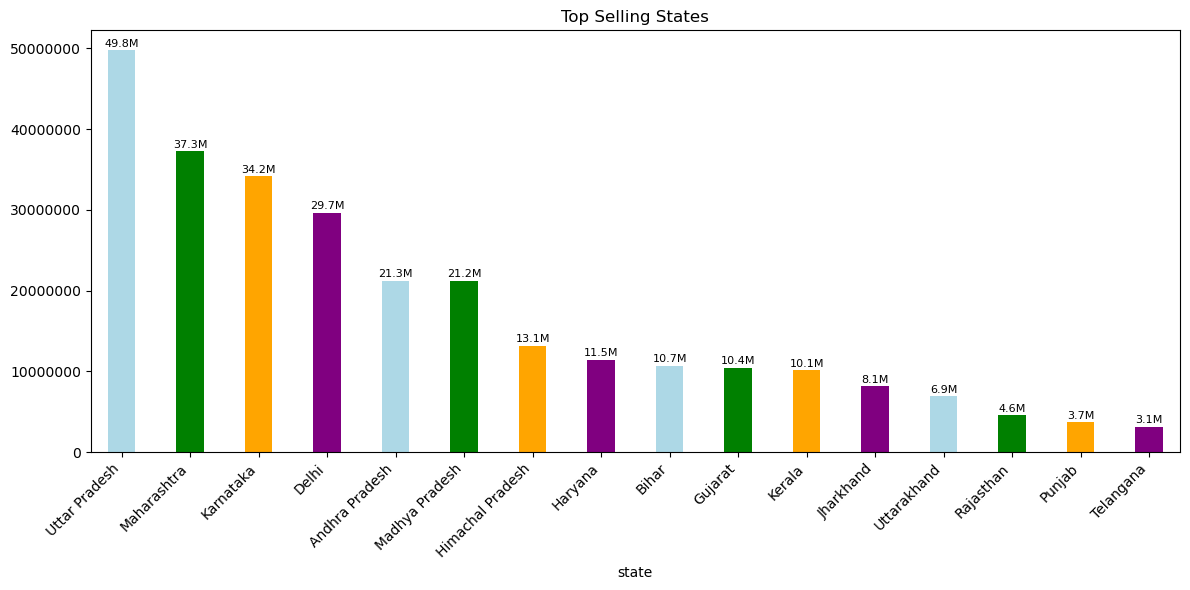

In [39]:
import matplotlib.pyplot as plt
colors = ['lightblue', 'green', 'orange', 'purple']
fig, ax = plt.subplots(figsize=(12,6))  # Increase figure size
ax = top_state.plot(kind='bar',color=colors, width=0.4,ax=ax)
plt.ticklabel_format(style='plain', axis='y')
plt.title("Top Selling States")
plt.xticks(rotation=90)
# Add values on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 200000, 
            f'{height/1000000:.1f}M', 
            ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
df.head(10)

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,total_sales,top_state,top_customer
1,1000732,Kartik,P00110942,F,26-35,35.0,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934,71802,NaN,595485
2,1502985,Bindu,P00118542,F,26-35,52.5,Married,Uttar Pradesh,Central,Automobile,Auto,4,35886,143544,NaN,143544
4,1000588,Joni,P00057942,M,26-35,28.0,Married,Gujarat,Western,Food Processing,Auto,2,23877,47754,NaN,317576
5,1500882,Joni,P00057942,M,26-35,42.0,Married,Himachal Pradesh,Northern,Food Processing,Auto,1,35815,35815,NaN,317576
6,1001132,Balk,P00018042,F,18-25,25.0,Married,Uttar Pradesh,Central,Lawyer,Auto,4,23841,95364,NaN,320492
8,1003224,Kushal,P00205642,M,26-35,35.0,Single,Uttar Pradesh,Central,Govt,Auto,2,23809,47618,NaN,474822
9,1003650,Ginny,P00031142,F,26-35,26.0,Married,Andhra Pradesh,Southern,Media,Auto,4,23799,95196,NaN,481141
10,1003829,Harshita,P00200842,M,26-35,34.0,Single,Delhi,Central,Banking,Auto,1,23770,23770,NaN,415001
11,1000214,Kargatis,P00119142,F,18-25,20.0,Single,Andhra Pradesh,Southern,Retail,Auto,2,23752,47504,NaN,180181
12,1004035,Elijah,P00080342,F,18-25,20.0,Married,Andhra Pradesh,Southern,IT Sector,Auto,2,23730,47460,NaN,162943


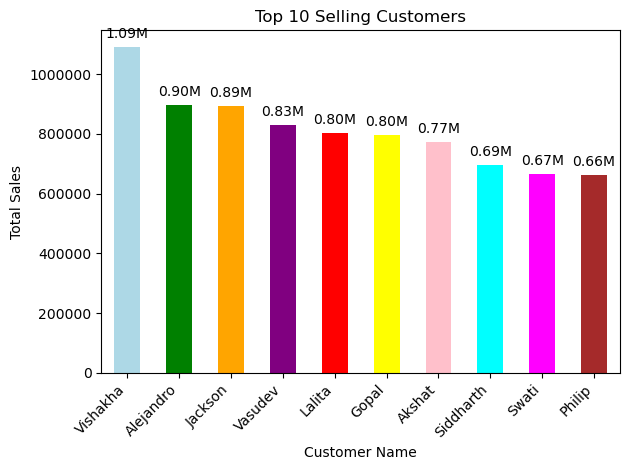

In [55]:
colors = ['lightblue', 'green', 'orange', 'purple', 'red',
          'yellow', 'pink', 'cyan', 'magenta', 'brown']

ax = top_customer.plot(kind='bar', color=colors)

plt.title("Top 10 Selling Customers")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')

#  Correct label placement for vertical bars

for bar in ax.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 20000,
             f'{height/1000000:.2f}M',
             ha='center', va='bottom')


plt.tight_layout()
plt.show()

In [46]:
gender_sales = df.groupby('gender')['total_sales'].sum().head(100)
print(gender_sales)

gender
F    193841424
M     81741224
Name: total_sales, dtype: int64


Highest spending gender: F


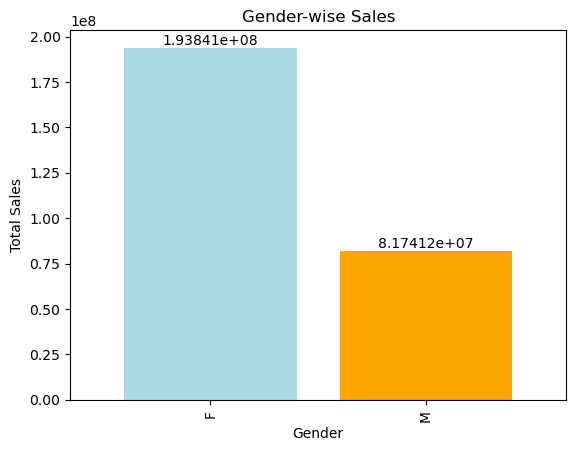

In [51]:
print("Highest spending gender:", gender_sales.idxmax())
colors=['lightblue','orange']
bar=gender_sales.plot(kind='bar',color=colors,width=0.8)

plt.title("Gender-wise Sales")
plt.xlabel("Gender")
plt.ylabel("Total Sales") 
for bars in bar.containers: bar.bar_label(bars) 
plt.show()


colors=['lightblue','orange']
bar=gender_sales.plot(kind='bar',color=colors,width=0.8) 

plt.title("Gender-wise Sales")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
for bars in bar.containers:
    bar.bar_label(bars)
plt.show()

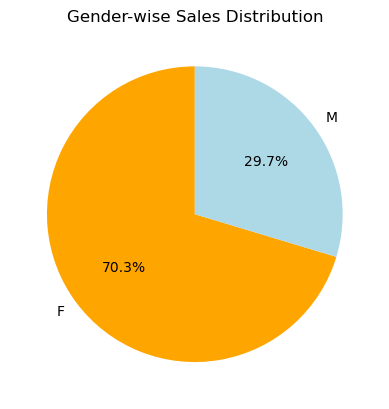

In [52]:
colors = ['orange', 'lightblue']

gender_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title("Gender-wise Sales Distribution")
plt.ylabel("")
plt.show()

df.head(50)

In [ ]:
#df.to_csv(r'C:\Users\ssbra\OneDrive\Documents\python _project\cleaned_data1.csv', index=False)

In [ ]:
df[df.isin(['Changed_Value']).any(axis=1)]

In [56]:
df.to_csv(r'C:\Users\ssbra\OneDrive\Documents\python _project\upcleaned_data1.csv', index=False)

The project shows that a few customers and regions generate most of the revenue, and customer demographics like age and gender influence buying behavior. These insights can help businesses focus on targeted marketing and customer retention.